In [244]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_curve, roc_auc_score, auc, precision_recall_curve
from sklearn.metrics import average_precision_score
from torchmetrics.classification import F1Score
from torchmetrics.classification import BinaryF1Score
from sklearn.preprocessing import label_binarize

from Bio import Entrez

import pandas as pd
import numpy as np
import os
import random
import time

import matplotlib.pyplot as plt
import seaborn as sns

import utils.parser as parser

In [53]:
# Process diagnosis data 
metadata = pd.read_csv('SJBae/all_metadata_contig_stats.csv')
diagnosis_data = metadata[['External ID', 'diagnosis']]
diagnosis_data = diagnosis_data.set_index(diagnosis_data.columns[0])

#print(diagnosis_data.shape)
diagnosis_data.head()
#counts = diagnosis_data['diagnosis'].value_counts()
#print(counts)

sampled_df = diagnosis_data.groupby("diagnosis").sample(n=2, random_state=1)
print(sampled_df)

            diagnosis
External ID          
MSMA26CV           CD
HSM67VHQ           CD
MSMB4LZR           UC
CSM5MCY8           UC
MSM9VZL9       nonIBD
MSM9VZOI       nonIBD


In [3]:
# Process taxonomic data - genus 

#genus_filtered_data = pd.read_csv('taxonomic_data/taxonomic_profiles_3_genus_filter.tsv', sep='\t', index_col=0)
#genus_filtered_data = genus_filtered_data.T

#print(genus_filtered_data.shape)
#genus_filtered_data.head()

(1638, 107)


/var/folders/xm/12wd_z4n7699_2f8bh9_6_7h0000gn/T/ipykernel_36362/2442204007.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


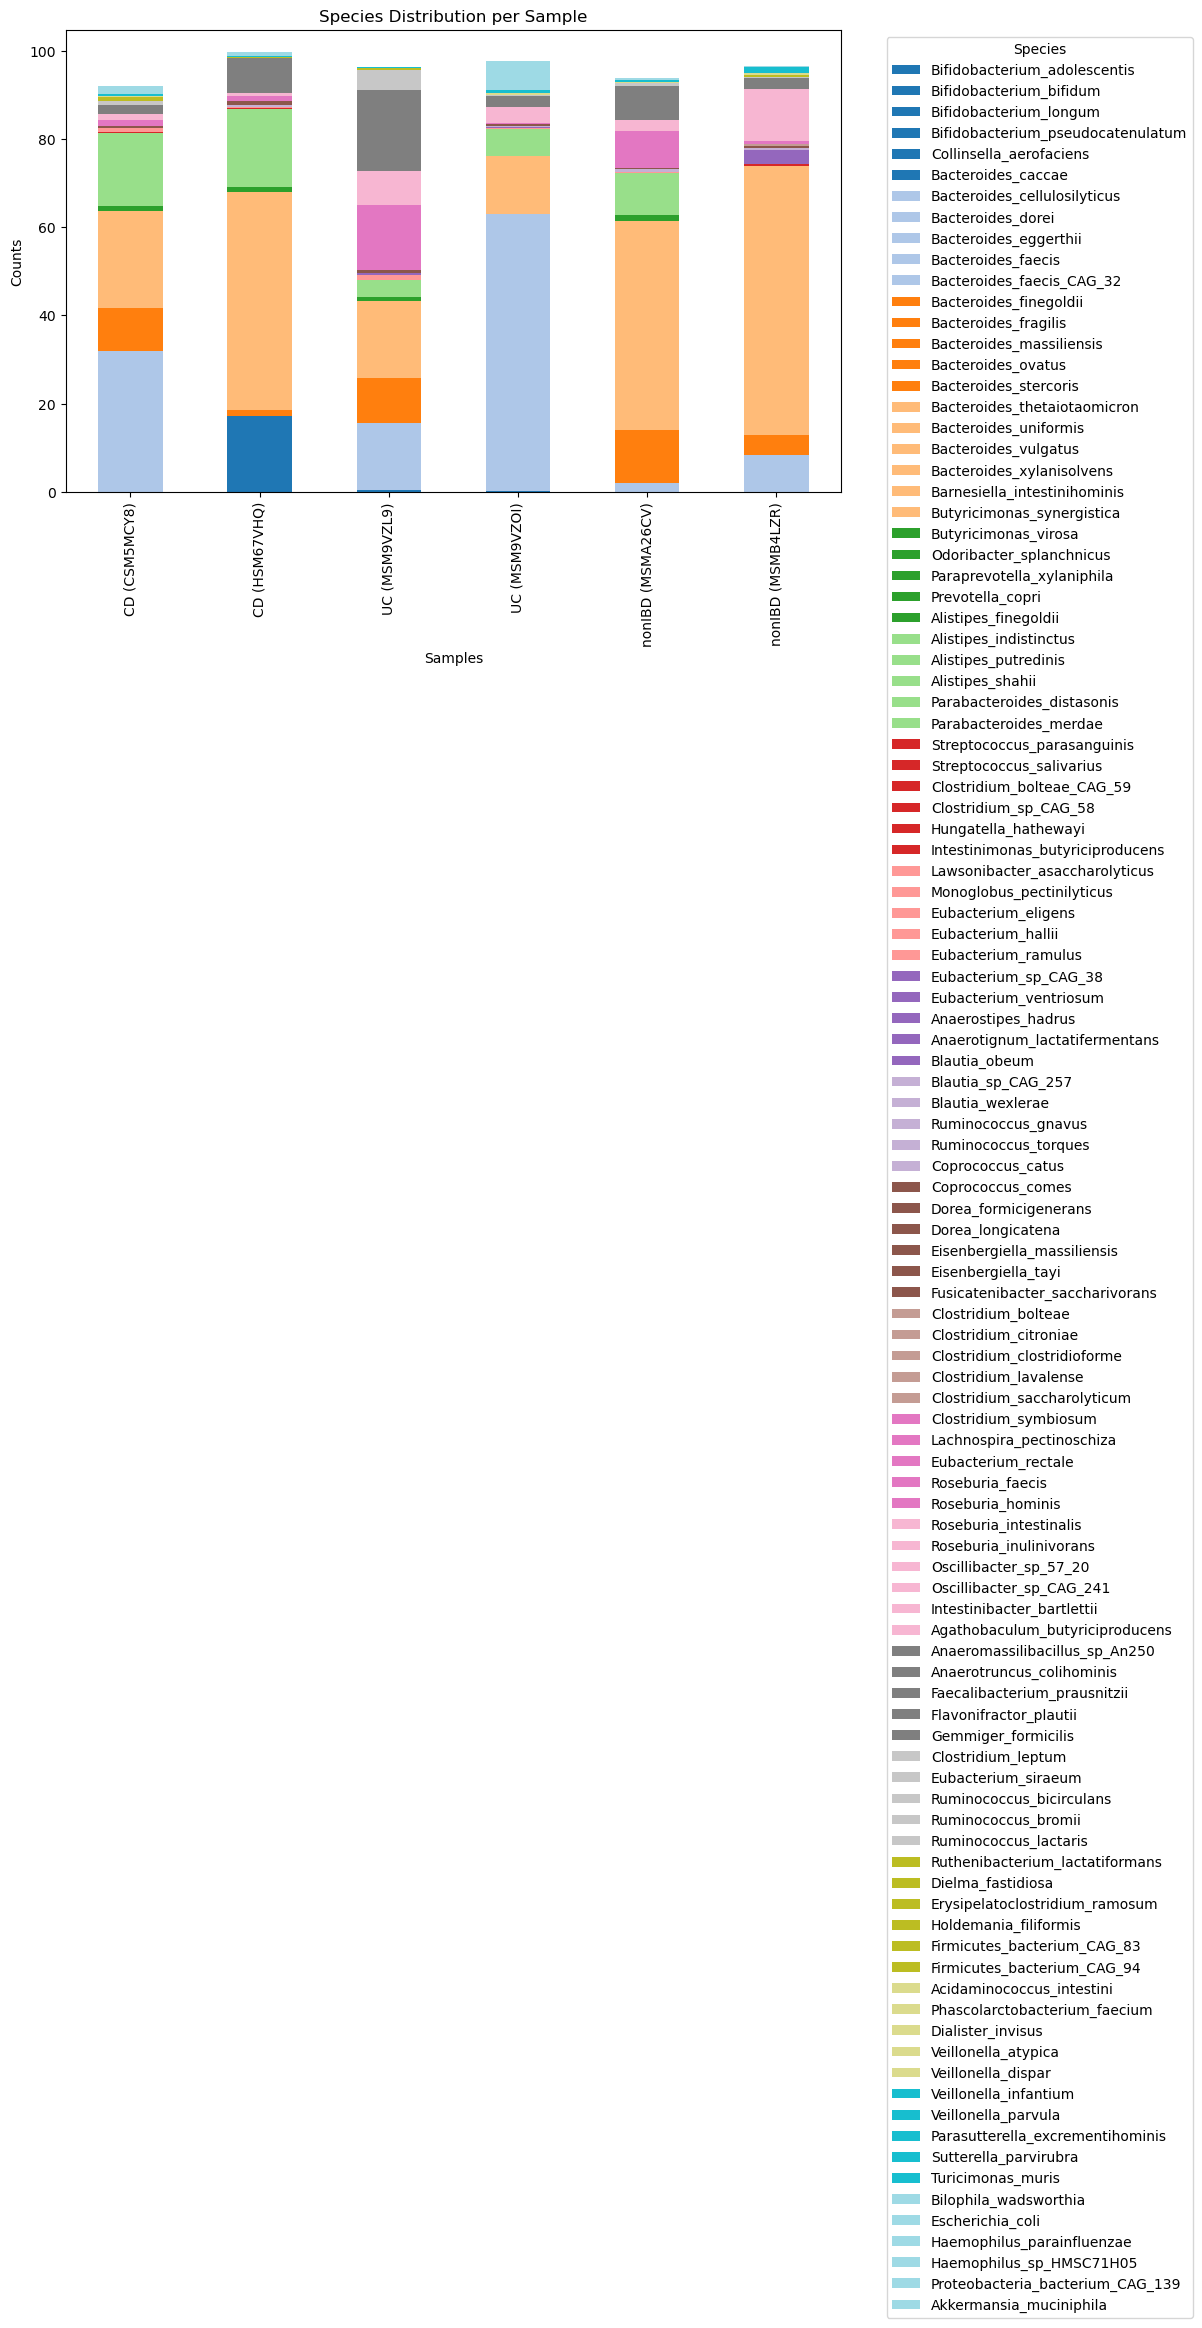

In [55]:
# Process taxonomic data - species 

species_filtered_data = pd.read_csv('taxonomic_data/taxonomic_profiles_3_species_filter.tsv', sep='\t', index_col=0)
species_filtered_data = species_filtered_data.T

print(species_filtered_data.shape)

# Make plots to visualize species distribution for select samples 

# Get list of External IDs
external_ids = sampled_df.index.unique()

# Filter species_filtered_data using IDs
df = species_filtered_data.loc[species_filtered_data.index.isin(external_ids)]
df.index = [f'{diagnosis} ({external_id})' for diagnosis, external_id in zip(sampled_df['diagnosis'], df.index)]

# Plotting stacked bar graph
ax = df.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
ax.set_ylabel('Counts')
ax.set_xlabel('Samples')
ax.set_title('Species Distribution per Sample')
plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [5]:
# Remove "_" from species names 
original_list = [item.replace("_", " ") for item in species_filtered_data.columns]

# Define fallback taxids for specific species
# From searching directly on NCBI website
fallback_taxids = {
    "Ruminococcus bicirculans": 3062497,
    "Clostridium clostridioforme": 1531,
    "Prevotella copri": 165179,
    "Bacteroides vulgatus": 821,
    "Bacteroides dorei": 357276,
    "Eubacterium rectale": 39491
}

# Use Entrez to get taxonomy IDs corresponding to species names
Entrez.email = ""
Entrez.api_key = ""

def get_taxid(species_name):
    handle = Entrez.esearch(db="taxonomy", term=species_name)
    record = Entrez.read(handle)
    handle.close()
    if record['IdList']:
        return record['IdList'][0]
    else:
        return fallback_taxids[species_name]

# Build a dictionary mapping species to taxonomy IDs
species_taxid_dict = {}
for species in original_list:
    taxid = get_taxid(species)
    species_taxid_dict[species] = taxid

# Convert all values to strings
species_taxid_dict = {key: str(value) for key, value in species_taxid_dict.items()}

In [6]:
# Extract the list of TaxIDs
taxid_list = species_taxid_dict.values()
#print(len(taxid_list))

accessions = {}

for taxid in taxid_list:
    
    time.sleep(0.5)
    
    # Search for genome assemblies for the given taxid
    handle = Entrez.esearch(db="assembly", term=f"txid{taxid}[Organism:exp]", retmax=1)
    record = Entrez.read(handle)
    handle.close()

    if record["IdList"]:
        asm_id = record["IdList"][0]
        summary_handle = Entrez.esummary(db="assembly", id=asm_id, report="full")
        summary = Entrez.read(summary_handle)
        summary_handle.close()

        docsum = summary['DocumentSummarySet']['DocumentSummary'][0]
        acc = docsum['AssemblyAccession']
        accessions[taxid] = acc
    else:
        accessions[taxid] = None

# Print results
#for taxid, acc in accessions.items():
#    print(f"TaxID: {taxid}, Accession: {acc}")

/opt/anaconda3/lib/python3.12/site-packages/Bio/Entrez/Parser.py:1077: UserWarning: Failed to save esummary_assembly.dtd at /Users/hy876/.config/biopython/Bio/Entrez/DTDs/esummary_assembly.dtd
  warnings.warn(f"Failed to save {filename} at {path}")


In [7]:
# Write accessions to file 
with open("accessions.txt", "w") as f:
    for acc in accessions.values():
        if acc.startswith("GCF_") or acc.startswith("GCA_"):
            f.write(f"{acc}\n")

In [8]:
# Run GtoTree to build a phylogenetic tree of accessions 

In [9]:
# Read GtoTree results 

from Bio import Phylo
from io import StringIO

accession_list = []

# Get accessions in the order they appear 
with open("microbiome_bac_tree2.tre", "r") as file:
    for line in file:
        if line.strip():  
            tree = Phylo.read(StringIO(line.strip()), "newick")
            accs = [term.name for term in tree.get_terminals()]
            accession_list.append(accs)

if len(accession_list) == 1:
    accession_list = accession_list[0]
    
#print(accession_list)

In [57]:
# Reverse the dictionary: accession to taxid
dict_acc_taxid = {v: str(k) for k, v in accessions.items()}

# Reverse the dictionary: taxid to species name
dict_taxid_species = {v: str(k) for k, v in species_taxid_dict.items()}

# Map accessions to taxids
taxid_list = [dict_acc_taxid.get(acc) for acc in accession_list]

# Map taxids to species names
ordered_species = [dict_taxid_species.get(tid) for tid in taxid_list]

#print(ordered_species)

# Replace spaces with underscores
ordered_species = [species.replace(" ", "_") for species in ordered_species]

# Reorder abundance data by species order
species_filtered_data_ordered = species_filtered_data[ordered_species]

Feature\Sample  Clostridium_saccharolyticum  Clostridium_symbiosum  \
CSM5FZ3N_P                          0.11127                0.01202   
CSM5FZ3R_P                          0.05395                0.00000   
CSM5FZ3T_P                          1.11002                0.00000   
CSM5FZ3V_P                          0.00023                0.00000   
CSM5FZ3X_P                          0.76847                0.00000   
...                                     ...                    ...   
PSMB4MBS                            0.00000                0.03915   
PSMB4MC1                            0.00000                0.07385   
PSMB4MC3                            0.00000                0.01559   
PSMB4MC5                            0.00000                0.00000   
PSMB4MC7                            0.00000                0.02581   

Feature\Sample  Hungatella_hathewayi  Clostridium_lavalense  \
CSM5FZ3N_P                   0.00000                0.00000   
CSM5FZ3R_P                   0.00

In [11]:
class AbundanceDataset(Dataset): 
    def __init__(self, abundances, labels, binary=False):
        self.abundances = abundances
        self.labels = labels

        if binary: 
            self.label_tokenizer = {"nonIBD":0, "CD":1, "UC": 1}
        else:
            self.label_tokenizer = {"nonIBD":0, "CD":1, "UC": 2}
        
        self.data = []
        for sample in abundances.index:
            features = abundances.loc[sample].values.astype(float)  # 1D array
            label = self.label_tokenizer[labels.loc[sample]]
            self.data.append((features, label))
            
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        features, label = self.data[idx]
        return torch.tensor(features, dtype=torch.float32), torch.tensor(label)

In [12]:
import torch.nn as nn
import torch.nn.functional as F

class Abundance1DCNN(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(2)
        self.fc1 = nn.Linear((n_features//2) * 32, 64)
        self.fc2 = nn.Linear(64, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)  
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)  
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [148]:
def compute_metrics(y_true, y_pred, binary=False):
    
    y_true = torch.stack(y_true).numpy().flatten().tolist()
    y_pred = torch.stack(y_pred).numpy().flatten().tolist()

    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred, average='binary' if binary else 'micro')
    precision = precision_score(y_true, y_pred, average='binary' if binary else 'micro')
    
    return accuracy, recall, precision


def plot_metrics_all_runs(epochs, all_metrics):

    epochs_range = range(1, epochs + 1)
    fig, axs = plt.subplots(3, 2, figsize=(12, 12))

    titles = ['Loss', 'Accuracy', 'Recall', 'Precision', 'F1 Score']
    ylabels = ['Loss', 'Accuracy', 'Recall', 'Precision', 'F1 Score']
    labels = [
        ('Train Loss', 'Test Loss'),
        ('Train Accuracy', 'Test Accuracy'),
        ('Train Recall', 'Test Recall'),
        ('Train Precision', 'Test Precision'),
        ('Train F1 Score', 'Test F1 Score')
    ]

    metric_indices = [
        (0, 1),  # loss
        (2, 3),  # accuracy
        (4, 5),  # recall
        (6, 7),  # precision
        (8, 9)   # f1
    ]

    for i, (title, ylabel, (train_label, test_label), (train_idx, test_idx)) in enumerate(zip(titles, ylabels, labels, metric_indices)):
        row = i // 2
        col = i % 2
        for run_metrics in all_metrics:
            axs[row, col].plot(epochs_range, run_metrics[train_idx], color='blue', alpha=0.3)
            axs[row, col].plot(epochs_range, run_metrics[test_idx], color='orange', alpha=0.3)
        axs[row, col].set_title(title)
        axs[row, col].set_xlabel('Epoch')
        axs[row, col].set_ylabel(ylabel)
        axs[row, col].legend([train_label, test_label], loc='lower left')

    plt.tight_layout()
    plt.show()


def plot_roc_pr_all_runs(roc_curves_all, pr_curves_all, class_names):
    """
    Plots all the ROC and PR curves from multiple runs on the same axes and shows the average AUC.

    Parameters:
    roc_curves_all : dict
        A dictionary with class names as keys and lists of (fpr, tpr, roc_auc) tuples from each run.
    pr_curves_all : dict
        A dictionary with class names as keys and lists of (recall, precision, pr_auc) tuples from each run.
    class_names : list
        A list of class names.
    """
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    colors = {'IBD':'green', 'Non-IBD':'purple', 'UC':'orange', 'CD':'gray'}

    # Plot ROC curves
    for class_name in class_names:
        auc_values = []
        
        for roc in roc_curves_all[class_name]:
            fpr, tpr, roc_auc = roc
            auc_values.append(roc_auc)
            axs[1].plot(fpr, tpr, color=colors[class_name], alpha=0.3)

        avg_roc_auc = np.mean(auc_values)
        axs[1].plot([], [], label=f'{class_name} Average AUROC={avg_roc_auc:.2f}', color=colors[class_name])

    axs[1].set_xlabel('False Positive Rate')
    axs[1].set_ylabel('True Positive Rate')
    axs[1].set_title('ROC Curve for All Runs')
    axs[1].legend(loc='lower right')

    # Plot PR curves
    for class_name in class_names:
        auc_values = []
        
        for pr in pr_curves_all[class_name]:
            recall, precision, pr_auc = pr
            auc_values.append(pr_auc)
            axs[0].plot(recall, precision, color=colors[class_name], alpha=0.3)

        avg_pr_auc = np.mean(auc_values)
        axs[0].plot([], [], label=f'{class_name} Average AUPR={avg_pr_auc:.2f}', color=colors[class_name])

    axs[0].set_xlabel('Recall')
    axs[0].set_ylabel('Precision')
    axs[0].set_title('Precision-Recall Curve for All Runs')
    axs[0].legend(loc='lower left')

    plt.tight_layout()
    plt.show()


In [172]:
def train_model(model, train_loader, test_loader, criterion, optimizer, device, epochs, binary): 

    # Make lists to hold metrics for plotting 
    train_losses, test_losses = [], []
    train_accuracies, test_accuracies = [], []
    train_recalls, test_recalls = [], []
    train_precisions, test_precisions = [], []
    train_f1, test_f1 = [], []

    if binary: 
        f1_metric = BinaryF1Score(threshold=0.5)
    else:
        f1_metric = F1Score(task="multiclass", num_classes=3, average='micro')

    start_time = time.time()
    
    for epoch in range(epochs):
    
        # Train model and evaluate
        model.train()
        preds = []
        ground = []
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, labels)
            
            loss.backward()
            optimizer.step()
            
            preds.extend(logits.argmax(dim=1).cpu().detach())
            ground.extend(labels.cpu().detach())
            
            running_loss += loss.item()
            
        train_accuracy, train_recall, train_precision = compute_metrics(ground, preds)
    
        train_losses.append(running_loss / len(train_loader))
        train_accuracies.append(train_accuracy)
        train_recalls.append(train_recall)
        train_precisions.append(train_precision)
        train_f1.append(f1_metric(torch.tensor(preds), torch.tensor(ground)))

        # Evaluate model on test set 
        model.eval()
        preds = []
        ground = []
        test_loss = 0.0
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                logits = model(inputs)    
                loss = criterion(logits, labels)
    
                preds.extend(logits.argmax(dim=1).cpu().detach())
                ground.extend(labels.cpu().detach()) 
                
                test_loss += loss.item()
    
        test_accuracy, test_recall, test_precision = compute_metrics(ground, preds)
        
        test_losses.append(test_loss / len(test_loader))
        test_accuracies.append(test_accuracy)
        test_recalls.append(test_recall)
        test_precisions.append(test_precision)
        test_f1.append(f1_metric(torch.tensor(preds), torch.tensor(ground)))

        '''
        if (epoch)%10==0:
            print(f"Epoch {epoch+1}/{epochs}")
            print(f"Train Loss: {running_loss/len(train_loader)}, Test Loss: {test_loss/len(test_loader)}")
            print(f"Train Accuracy: {train_accuracy:.4f}, Train Recall: {train_recall:.4f}, Train Precision: {train_precision:.4f}")
            print(f"Test Accuracy: {test_accuracy:.4f}, Test Recall: {test_recall:.4f}, Test Precision: {test_precision:.4f}\n")
        '''

    end_time = time.time()
    #print(f"Time to train: {end_time-start_time:.2f} seconds\n")

    metrics = [train_losses, test_losses, 
               train_accuracies, test_accuracies, 
               train_recalls, test_recalls, 
               train_precisions, test_precisions,
               train_f1, test_f1]

    return model, metrics 

In [182]:
def train_and_evaluate(taxonomic_data, diagnosis_data, binary, device, epochs, batch_size):
    '''
    Trains and evaluates a 1D CNN on taxonomic abundance data.

    Parameters
        taxonomic_data : pd.DataFrame
            DataFrame of abundances for each sample (samples x features).
        diagnosis_data : pd.DataFrame
            DataFrame with a 'diagnosis' column for each sample.
        binary : bool
            True for healthy vs disease, False for CD vs UC vs healthy.
        device : torch.device
            Device to train on.
        epochs : int
            Number of training epochs.
        batch_size : int
            Batch size for training and evaluation.

    Returns
        metrics : list 
            List of metric lists for plotting.
        
    '''
    # Align features and labels by sample 
    X = taxonomic_data  
    y = diagnosis_data['diagnosis'].reindex(taxonomic_data.index)
    
    # Split data into train and test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

    # Create datasets and loaders
    train_dataset = AbundanceDataset(X_train, y_train, binary=binary)
    test_dataset = AbundanceDataset(X_test, y_test, binary=binary)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    # Model setup
    n_features = X.shape[1]
    n_classes = 2 if binary else 3

    model = Abundance1DCNN(n_features, n_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # Train and evaluate
    model, metrics = train_model(model, train_loader, test_loader, criterion, optimizer, device, epochs, binary)

    probs = []
    targets = []
    model.eval()
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs.to(device))
            prob = F.softmax(outputs, dim=1).cpu().numpy() 
            label = labels.cpu().numpy()                 
            probs.append(prob)
            targets.append(label)

    probs = np.concatenate(probs, axis=0)  
    targets = np.concatenate(targets, axis=0)  

    # Dictionaries to hold PR and ROC curve values and AUCs
    pr_curves = {}
    roc_curves = {}
    
    if binary: 
        # For class 1 as positive
        y_true_1 = targets
        y_score_1 = probs[:, 1]
        
        # For class 0 as positive
        y_true_0 = 1 - targets
        y_score_0 = probs[:, 0]
        
        # Compute metrics
        fpr1, tpr1, _ = roc_curve(y_true_1, y_score_1)
        roc_auc1 = auc(fpr1, tpr1)
        precision1, recall1, _ = precision_recall_curve(y_true_1, y_score_1)
        pr_auc1 = average_precision_score(y_true_1, y_score_1)
        
        fpr0, tpr0, _ = roc_curve(y_true_0, y_score_0)
        roc_auc0 = auc(fpr0, tpr0)
        precision0, recall0, _ = precision_recall_curve(y_true_0, y_score_0)
        pr_auc0 = average_precision_score(y_true_0, y_score_0)

        pr_curves = {
            'IBD': [recall1, precision1, pr_auc1],
            'Non-IBD': [recall0, precision0, pr_auc0]
        }

        roc_curves = {
            'IBD': [fpr1, tpr1, roc_auc1],
            'Non-IBD': [fpr0, tpr0, roc_auc0]
        }
        

    else:

        n_classes = probs.shape[1]
        targets_bin = label_binarize(targets, classes=np.arange(n_classes))

        class_names = ['Non-IBD', 'CD', 'UC']
        
        for i in range(n_classes):
            y_true = targets_bin[:, i]
            y_score = probs[:, i]
            if np.unique(y_true).size > 1:
                fpr, tpr, _ = roc_curve(y_true, y_score)
                roc_auc = auc(fpr, tpr)

                roc_curves[class_names[i]] = [fpr, tpr, roc_auc]
        
                precision, recall, _ = precision_recall_curve(y_true, y_score)
                pr_auc = average_precision_score(y_true, y_score)

                pr_curves[class_names[i]] = [recall, precision, pr_auc]
        
    
    return model, metrics, roc_curves, pr_curves

In [48]:
# Set device
device = 'mps' if torch.mps.is_available() else 'cpu'

In [170]:
def run_multiple_trainings(species_data, diagnosis_data, class_names, binary, device, epochs, batch_size, n_runs=20):
    """
    Trains and evaluates the model multiple times, collecting metrics and curve data.

    Parameters:
        species_data : Dataframe, Taxonomic data.
        diagnosis_data : Dataframe, Diagnosis labels.
        class_names : list, Names of classes.
        binary : boolean, Binary classification if True, otherwise multiclass
        device : torch.device, Device to train the model on.
        epochs : int, Number of epochs for each training run.
        batch_size : int, Batch size.
        n_runs : int, Number of training runs.

    Returns:
        all_metrics : list
            List of metric lists for all runs.
        roc_curves_all : dict
            ROC curves for each class across runs.
        pr_curves_all : dict
            PR curves for each class across runs.
    """

    all_metrics = []
    pr_curves_all = {name: [] for name in class_names}
    roc_curves_all = {name: [] for name in class_names}

    for i in range(n_runs):
        #print(f"Training run {i+1}/{n_runs}")
        model, metrics, roc_curves, pr_curves = train_and_evaluate(
            species_data, diagnosis_data, binary=binary,
            device=device, epochs=epochs, batch_size=batch_size
        )
        all_metrics.append(metrics)

        for name in class_names:
            if name in pr_curves:
                pr_rec, pr_prec, pr_auc = pr_curves[name]
                pr_curves_all[name].append((pr_rec, pr_prec, pr_auc))

            if name in roc_curves:
                roc_fpr, roc_tpr, roc_auc = roc_curves[name]
                roc_curves_all[name].append((roc_fpr, roc_tpr, roc_auc))

    return all_metrics, roc_curves_all, pr_curves_all

In [326]:
# Shuffle the columns of species data
shuffled_columns = np.random.permutation(species_filtered_data.columns)
species_filtered_data_shuffled = species_filtered_data[shuffled_columns]

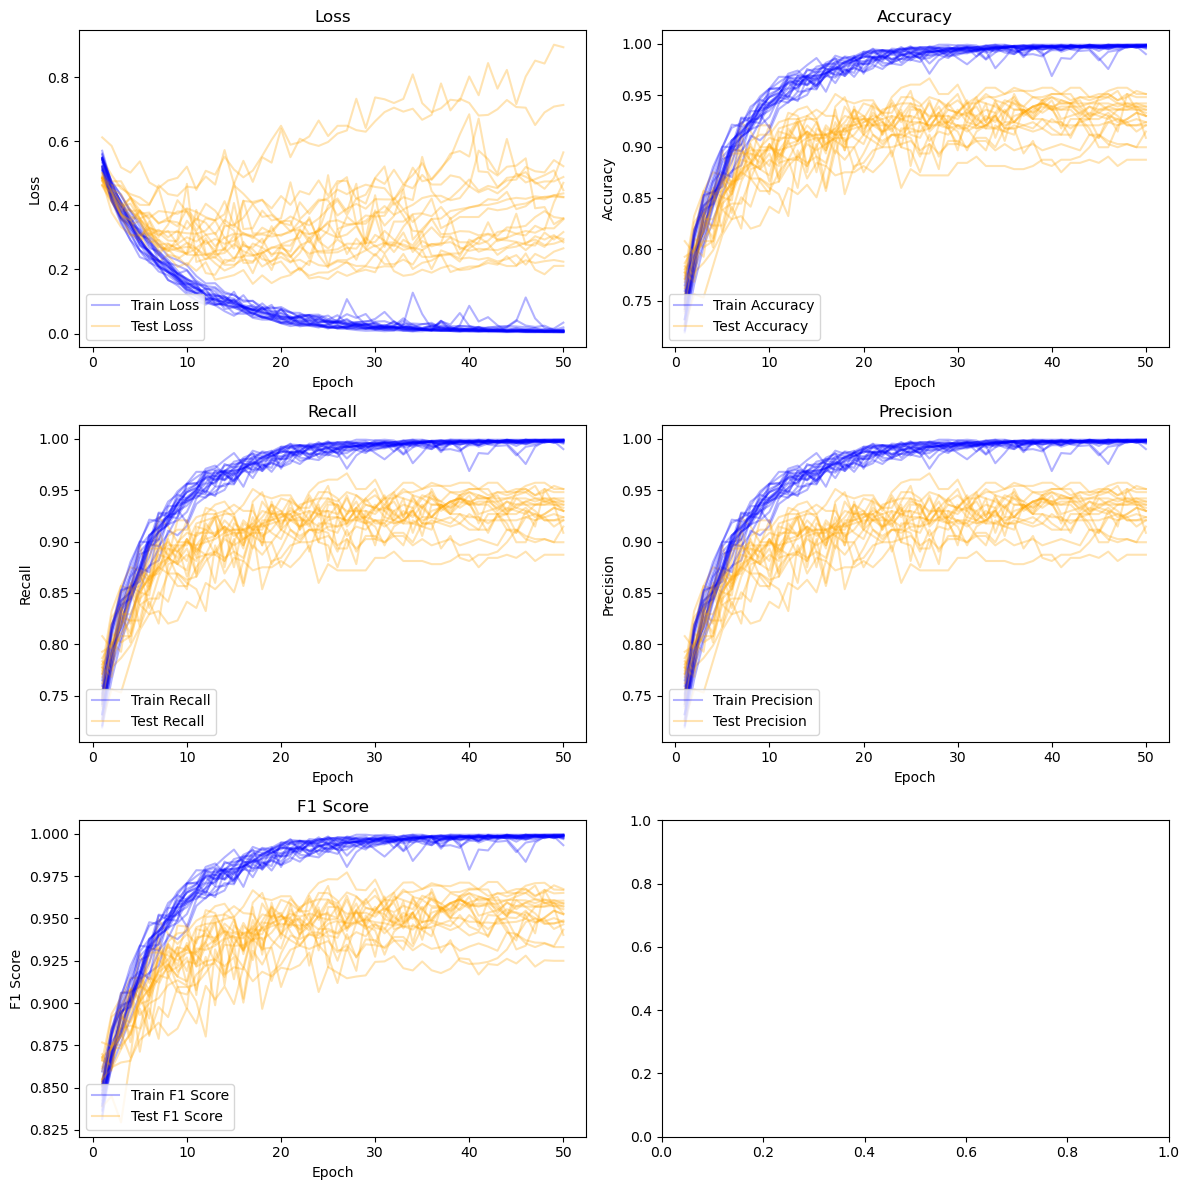

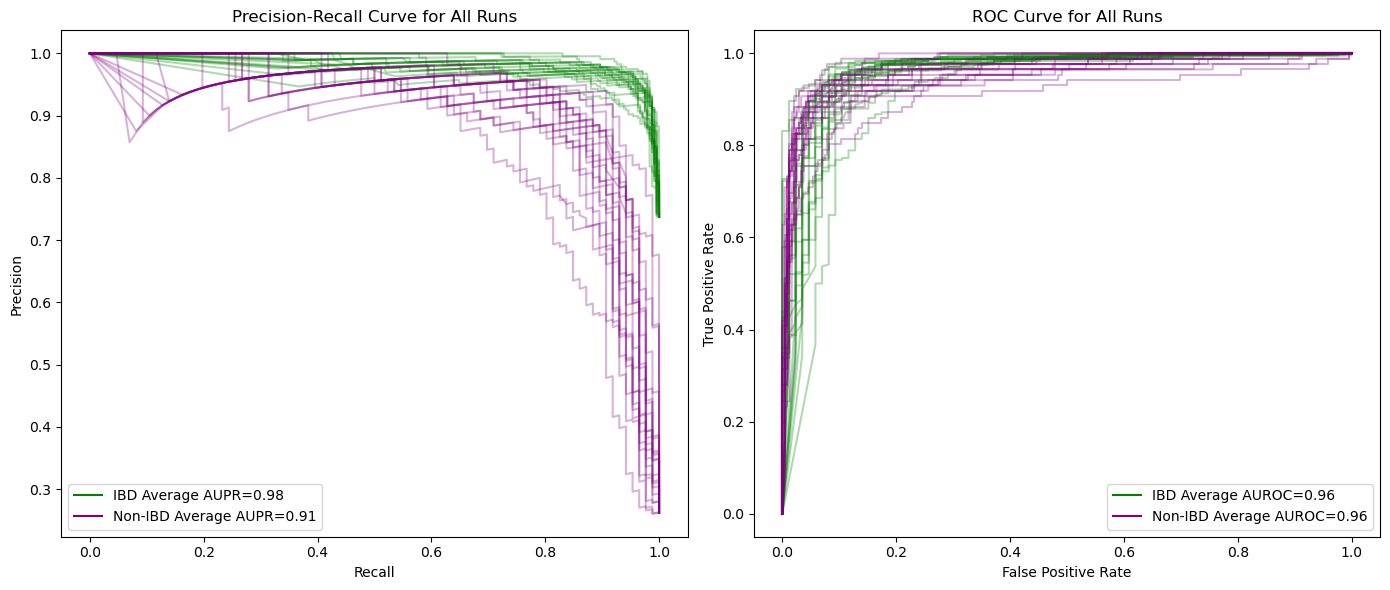

In [328]:
# Binary prediction (healthy vs disease) with filtered species data 
class_names = ['IBD', 'Non-IBD']

# Unordered species 
metrics_bin_unordered, roc_curves_bin_unordered, pr_curves_bin_unordered = run_multiple_trainings(
    species_data=species_filtered_data_shuffled,
    diagnosis_data=diagnosis_data,
    class_names=class_names,
    binary=True,
    device=device,
    epochs=50,
    batch_size=32,
    n_runs=20
)

plot_metrics_all_runs(epochs=50, all_metrics=metrics_bin_unordered)
plot_roc_pr_all_runs(roc_curves_bin_unordered, pr_curves_bin_unordered, class_names)

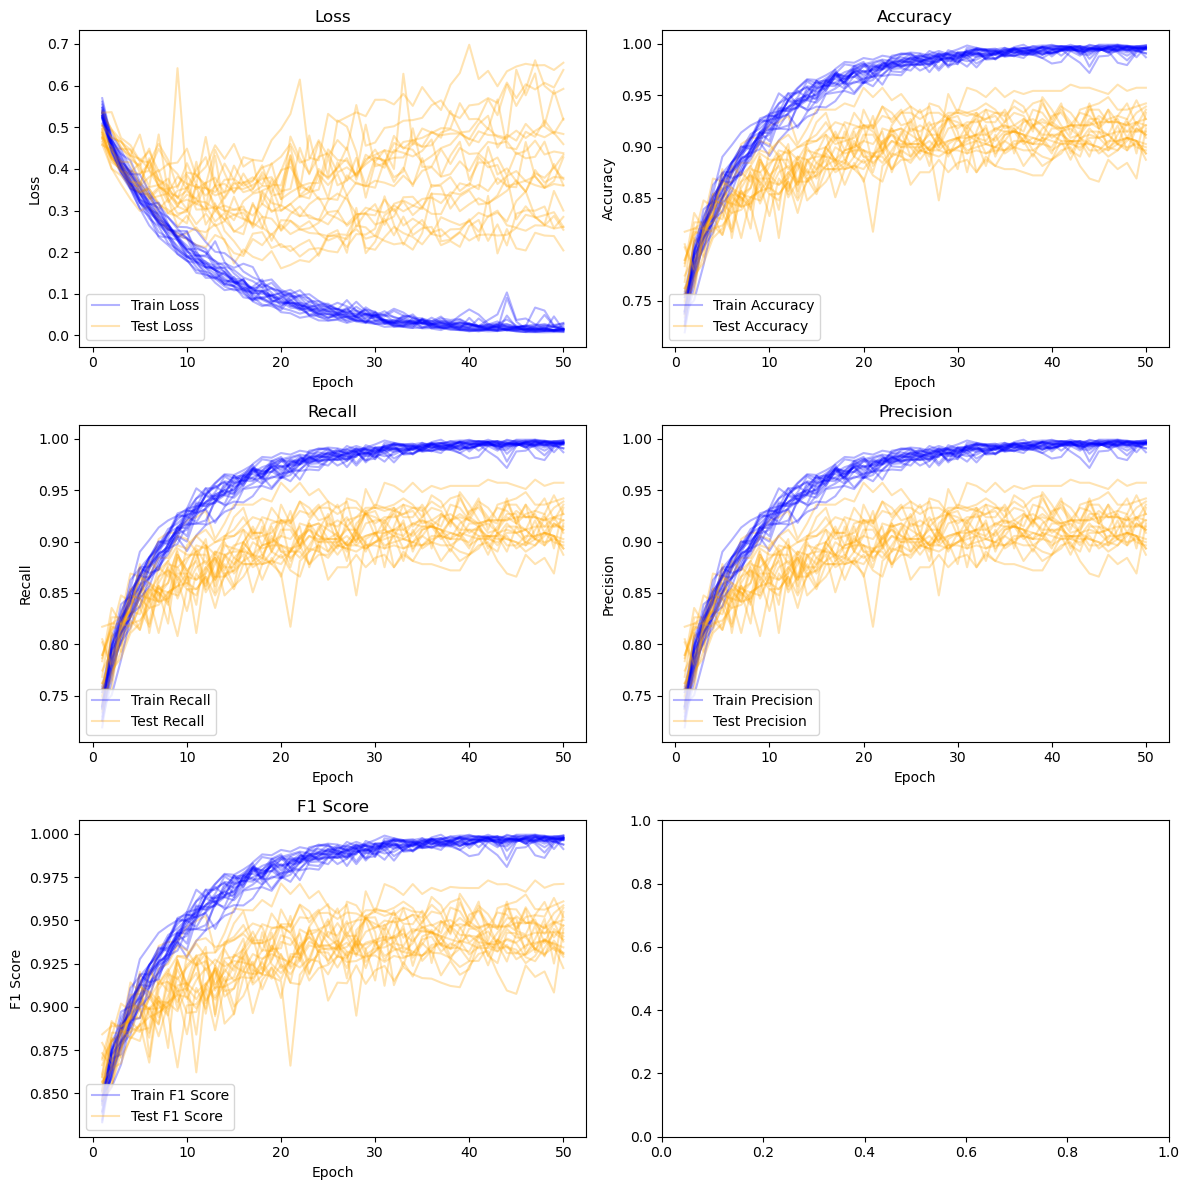

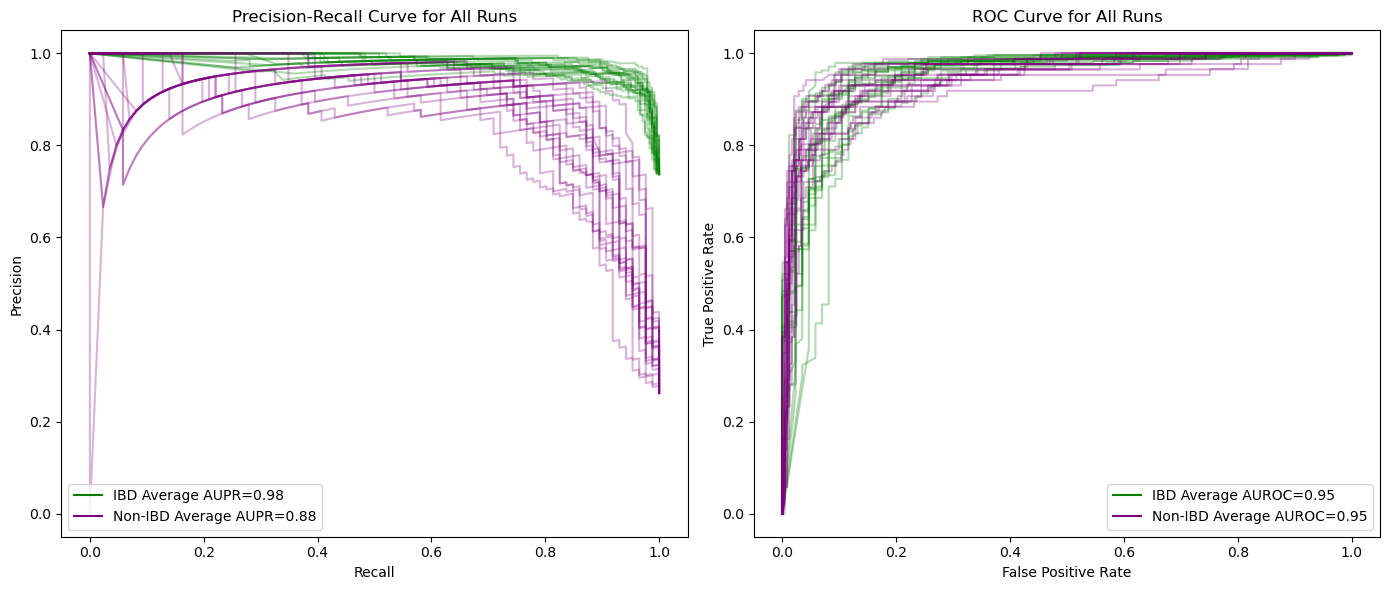

In [329]:
# Binary 
# Ordered_species
metrics_bin_ordered, roc_curves_bin_ordered, pr_curves_bin_ordered = run_multiple_trainings(
    species_data=species_filtered_data_ordered,
    diagnosis_data=diagnosis_data,
    class_names=class_names,
    binary=True,
    device=device,
    epochs=50,
    batch_size=32,
    n_runs=20
)

plot_metrics_all_runs(epochs=50, all_metrics=metrics_bin_ordered)
plot_roc_pr_all_runs(roc_curves_bin_ordered, pr_curves_bin_ordered, class_names)

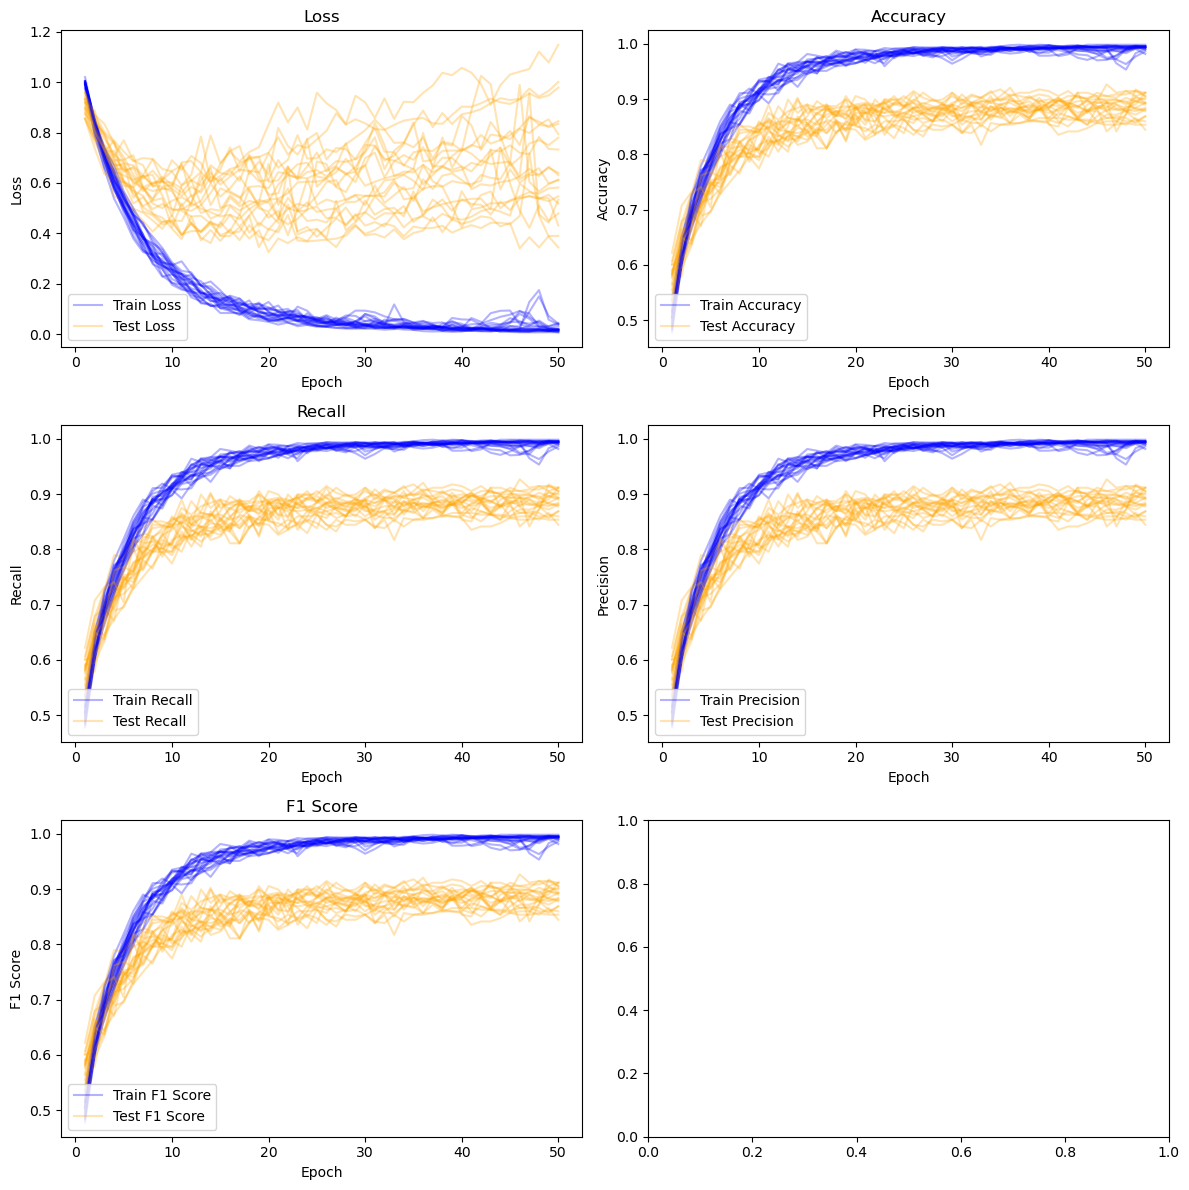

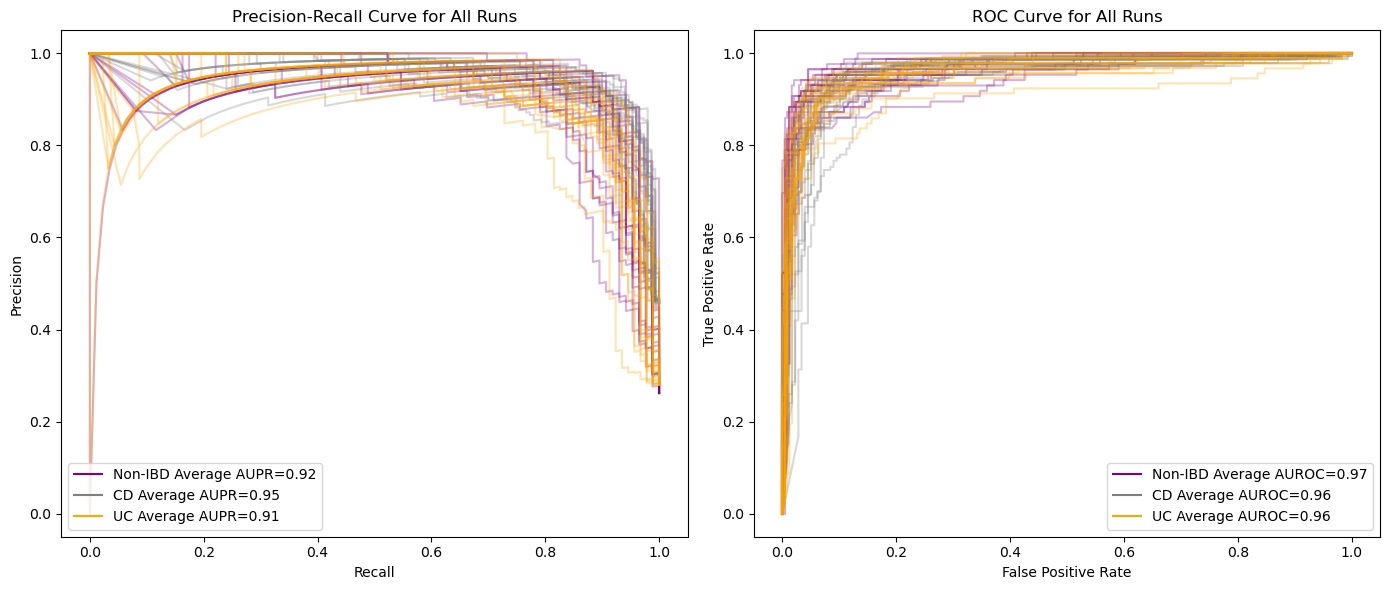

In [330]:
# CD vs UC vs healthy prediction with filtered species data 
class_names = ['Non-IBD', 'CD', 'UC']

# Unordered species
metrics_diag_unordered, roc_curves_diag_unordered, pr_curves_diag_unordered = run_multiple_trainings(
    species_data=species_filtered_data_shuffled,
    diagnosis_data=diagnosis_data,
    class_names=class_names,
    binary=False,
    device=device,
    epochs=50,
    batch_size=32,
    n_runs=20
)

plot_metrics_all_runs(epochs=50, all_metrics=metrics_diag_unordered)
plot_roc_pr_all_runs(roc_curves_diag_unordered, pr_curves_diag_unordered, class_names)

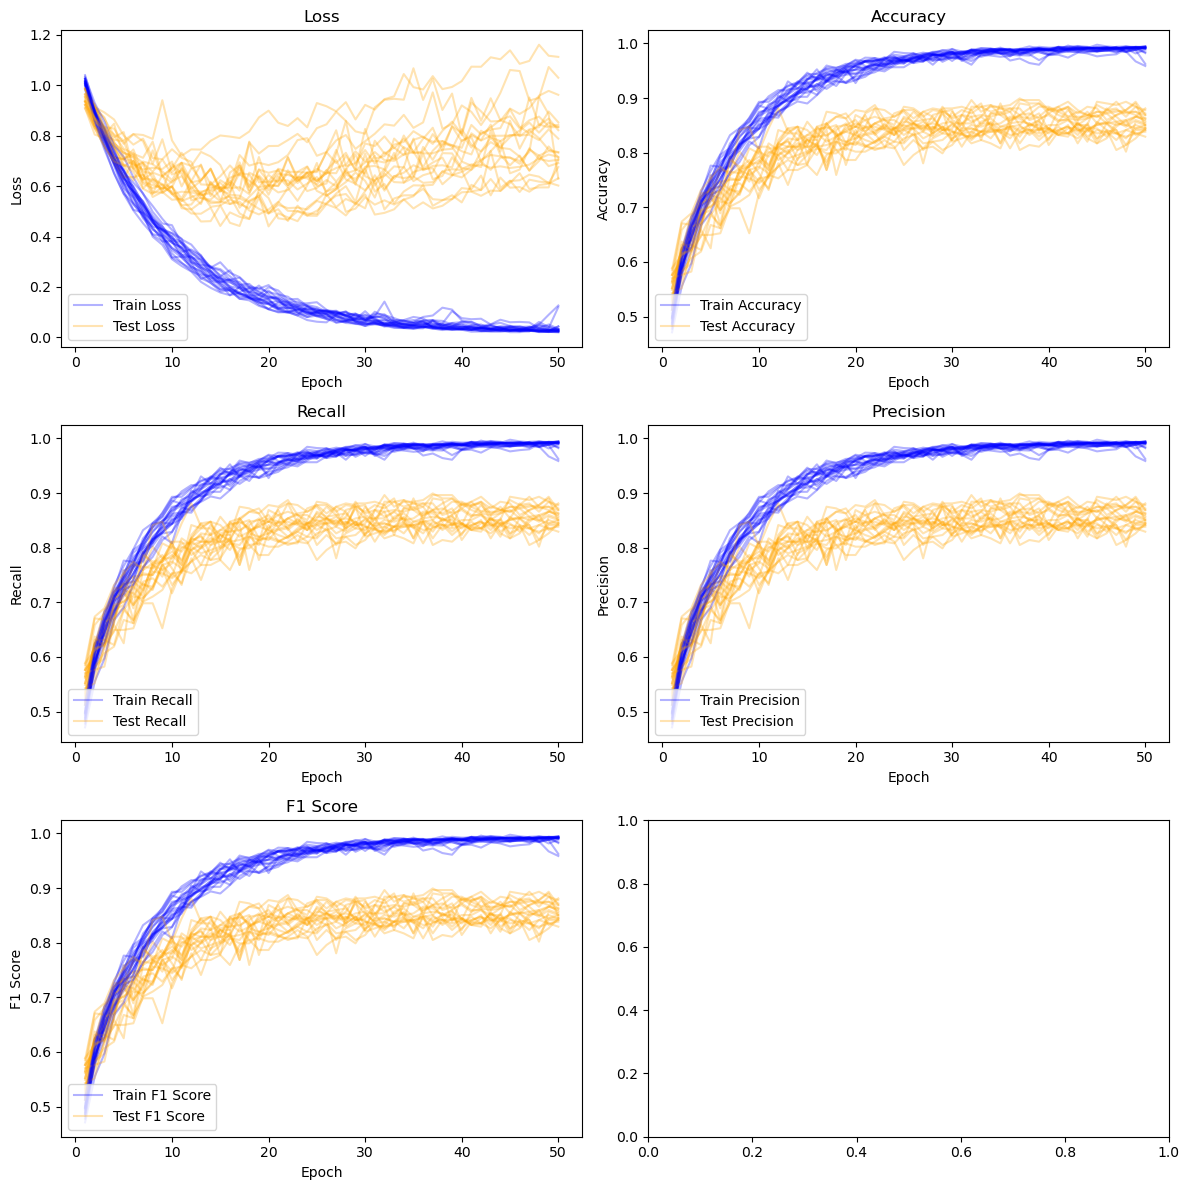

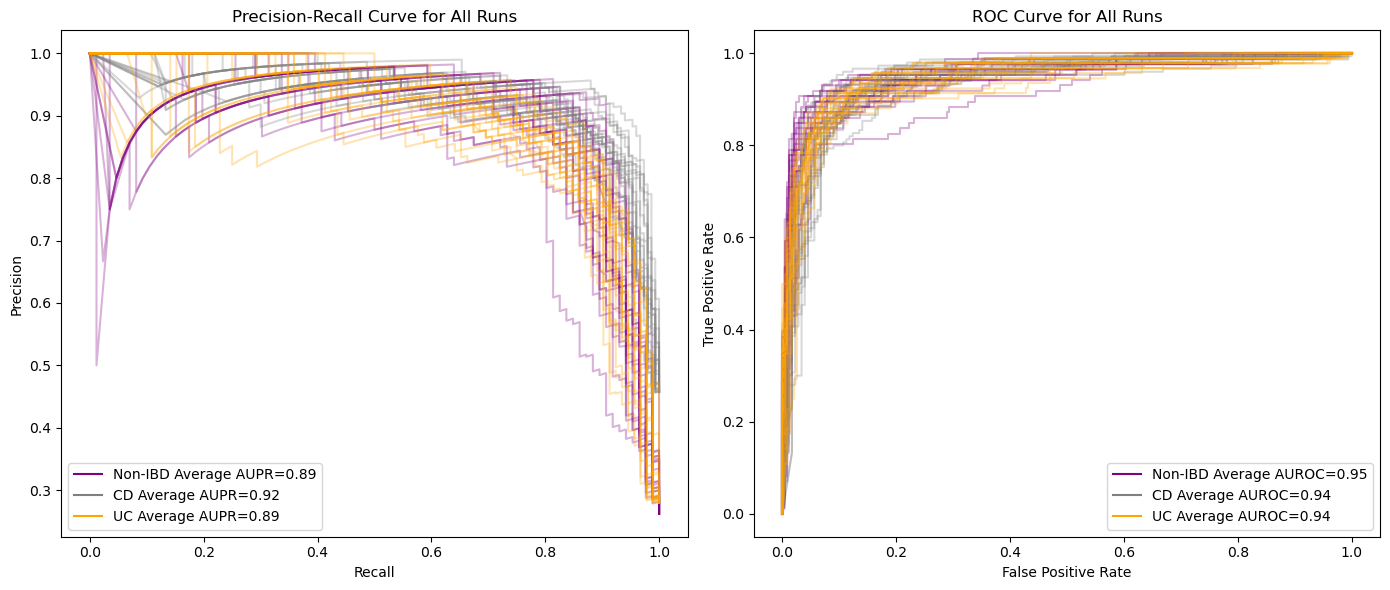

In [331]:
# CD vs UC vs healthy
# Ordered species
metrics_diag_ordered, roc_curves_diag_ordered, pr_curves_diag_ordered = run_multiple_trainings(
    species_data=species_filtered_data_ordered,
    diagnosis_data=diagnosis_data,
    class_names=class_names,
    binary=False,
    device=device,
    epochs=50,
    batch_size=32,
    n_runs=20
)

plot_metrics_all_runs(epochs=50, all_metrics=metrics_diag_ordered)
plot_roc_pr_all_runs(roc_curves_diag_ordered, pr_curves_diag_ordered, class_names)

In [63]:
# Binary prediction (healthy vs disease) with filtered genus data 
#model = train_and_evaluate(genus_filtered_data, diagnosis_data, binary=True, device=device, epochs=50, batch_size=32)

In [65]:
# CD vs UC vs healthy prediction with filtered genus data 
#model = train_and_evaluate(genus_filtered_data, diagnosis_data, binary=False, device=device, epochs=50, batch_size=32)

In [342]:
def compare_final_metrics(unordered_metrics, ordered_metrics):
    """
    Plot the final (last epoch) value of each metric for unordered and ordered species,
    show the average value, and test for statistical significance.

    Parameters:
        unordered_metrics : list of lists, Each inner list is a list of metric values over epochs for a run.
        ordered_metrics : list of lists, Same as above but for ordered species.
    """

    metric_names = ['Loss', 'Accuracy', 'Recall', 'Precision', 'F1 Score']
    
    unordered_final = np.array([np.array(run)[:, -1] for run in unordered_metrics])
    ordered_final = np.array([np.array(run)[:, -1] for run in ordered_metrics])

    fig, axs = plt.subplots(5, 1, figsize=(8, 10))
    axs = axs.flatten()  

    for i, metric in enumerate(metric_names):
        ax = axs[i]
        metric_data = [unordered_final[:, i], ordered_final[:, i]]
        combined = np.concatenate(metric_data)
        labels = ['Unordered'] * len(metric_data[0]) + ['Ordered'] * len(metric_data[1])

        sns.boxplot(x=labels, y=combined, ax=ax, palette='husl', showmeans=True,
                    meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"})
        
        sns.stripplot(x=labels, y=combined, color='black', alpha=0.6, jitter=True, ax=ax)

        # t-test
        t_stat, p_val = ttest_ind(metric_data[0], metric_data[1])
        ax.set_title(f"{metric}\n(p = {p_val:.3e})")

        # Annotate means
        mean_unordered = np.mean(metric_data[0])
        mean_ordered = np.mean(metric_data[1])
        y_max = combined.max() 
        ax.text(-0.2, y_max, f"{mean_unordered:.2f}", ha='center', va='center', fontsize=12)
        ax.text(1.2, y_max, f"{mean_ordered:.2f}", ha='center', va='center', fontsize=12)

        ax.set_ylabel(metric)

    plt.tight_layout()
    plt.show()

/var/folders/xm/12wd_z4n7699_2f8bh9_6_7h0000gn/T/ipykernel_36362/246143356.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=labels, y=combined, ax=ax, palette='husl', showmeans=True,
/var/folders/xm/12wd_z4n7699_2f8bh9_6_7h0000gn/T/ipykernel_36362/246143356.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=labels, y=combined, ax=ax, palette='husl', showmeans=True,
/var/folders/xm/12wd_z4n7699_2f8bh9_6_7h0000gn/T/ipykernel_36362/246143356.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=labels, y=combined, ax=ax, palette='hus

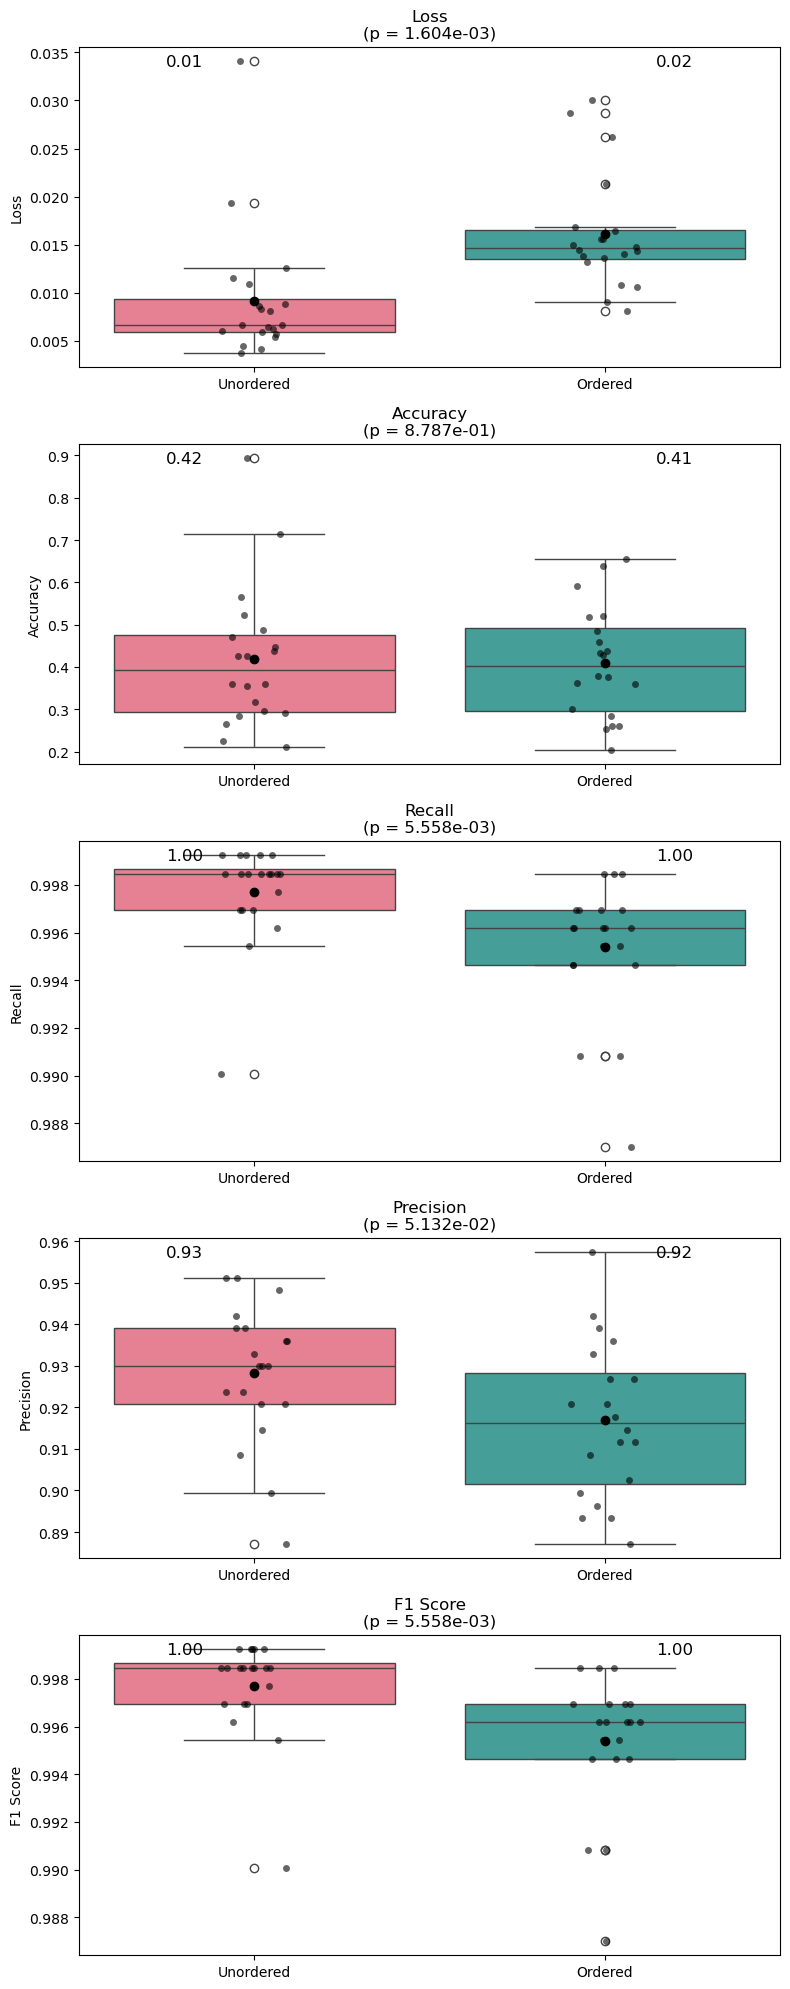

In [333]:
# Compare performance metrics for binary classification
compare_final_metrics(metrics_bin_unordered, metrics_bin_ordered)

/var/folders/xm/12wd_z4n7699_2f8bh9_6_7h0000gn/T/ipykernel_36362/246143356.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=labels, y=combined, ax=ax, palette='husl', showmeans=True,
/var/folders/xm/12wd_z4n7699_2f8bh9_6_7h0000gn/T/ipykernel_36362/246143356.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=labels, y=combined, ax=ax, palette='husl', showmeans=True,
/var/folders/xm/12wd_z4n7699_2f8bh9_6_7h0000gn/T/ipykernel_36362/246143356.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=labels, y=combined, ax=ax, palette='hus

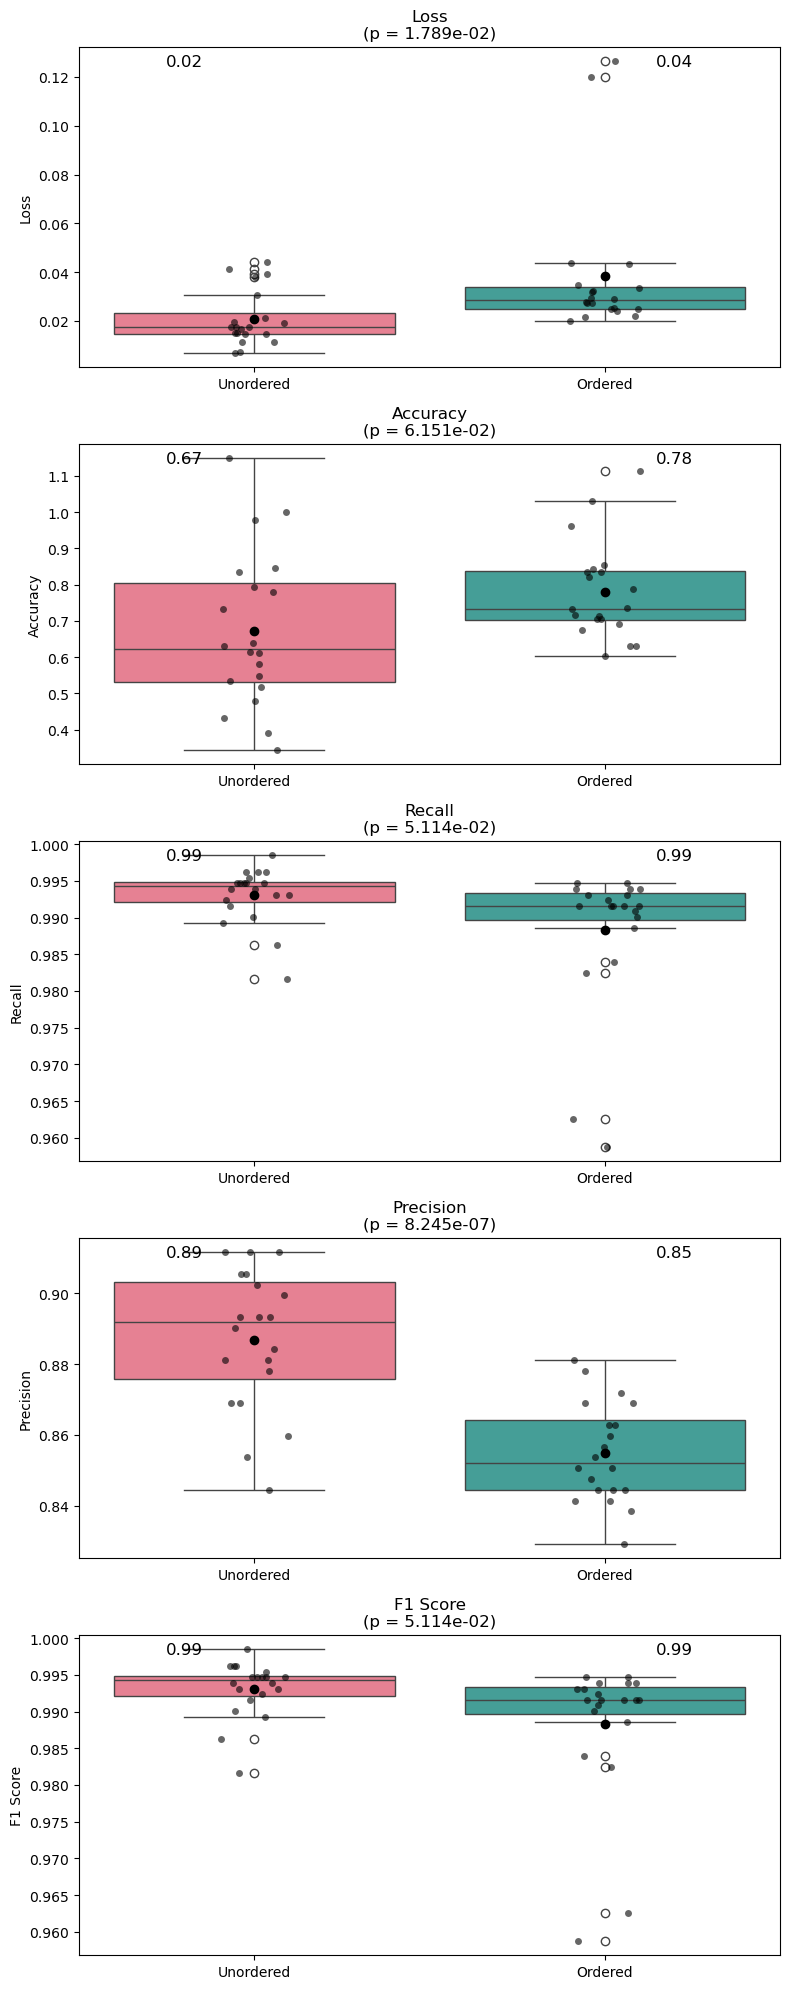

In [334]:
# Compare performance metrics for Healthy vs CD vs UC 
compare_final_metrics(metrics_diag_unordered, metrics_diag_ordered)